This notebook is to visualize the mass distribution plot for common envelope alpha variations

### Imports and definitions

In [1]:
import h5py as h5 
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
import tol_colors as tc

import useful_fncs
import utils_from_others
import figure_utils
import mass_dist_fnc

# plotting imports
# import for axes labels 
plt.rc('text.latex', preamble=r'\usepackage{textgreek}')
plt.rc('font', family='serif')
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "sans-serif"
})

### Let's use our function to gather our data

In [2]:
pathToH5_NSNS_025 = '/expanse/lustre/scratch/msantiago/temp_project/v03.21.00/COMPAS_DATA/v03.21.00/N5e6_NSNS_CE_alpha025/MainRun/COMPAS_Output_wWeights.h5'
pathToH5_WDWD_025 = '/expanse/lustre/scratch/msantiago/temp_project/v03.21.00/COMPAS_DATA/v03.21.00/N5e6_MassiveWDWD_NSNS_CE_alpha025/MainRun/COMPAS_Output_wWeights.h5'

local_rates_025, masses_025 = mass_dist_fnc.mass_dis_info(pathToH5_NSNS_025, pathToH5_WDWD_025)

In [7]:
pathToH5_NSNS_05 = '/expanse/lustre/scratch/msantiago/temp_project/v03.21.00/COMPAS_DATA/v03.21.00/N5e6_NSNS_CE_alpha05/MainRun/COMPAS_Output_wWeights.h5'
pathToH5_WDWD_05 = '/expanse/lustre/scratch/msantiago/temp_project/v03.21.00/COMPAS_DATA/v03.21.00/N5e6_MassiveWDWD_NSNS_CE_alpha05/MainRun/COMPAS_Output_wWeights.h5'

local_rates_05, masses_05 = mass_dist_fnc.mass_dis_info(pathToH5_NSNS_05, pathToH5_WDWD_05)

In [8]:
pathToH5_NSNS_075 = '/expanse/lustre/scratch/msantiago/temp_project/v03.21.00/COMPAS_DATA/v03.21.00/N5e6_NSNS_CE_alpha075/MainRun/COMPAS_Output_wWeights.h5'
pathToH5_WDWD_075 = '/expanse/lustre/scratch/msantiago/temp_project/v03.21.00/COMPAS_DATA/v03.21.00/N5e6_MassiveWDWD_NSNS_CE_alpha075/MainRun/COMPAS_Output_wWeights.h5'

local_rates_075, masses_075 = mass_dist_fnc.mass_dis_info(pathToH5_NSNS_075, pathToH5_WDWD_075)

In [9]:
pathToH5_NSNS_2 = '/expanse/lustre/scratch/msantiago/temp_project/v03.21.00/COMPAS_DATA/v03.21.00/N5e6_NSNS_CE_alpha2/MainRun/COMPAS_Output_wWeights.h5'
pathToH5_WDWD_2 = '/expanse/lustre/scratch/msantiago/temp_project/v03.21.00/COMPAS_DATA/v03.21.00/N5e6_MassiveWDWD_NSNS_CE_alpha2/MainRun/COMPAS_Output_wWeights.h5'

local_rates_2, masses_2 = mass_dist_fnc.mass_dis_info(pathToH5_NSNS_2, pathToH5_WDWD_2)

### Plotting the DWD Subpopulations

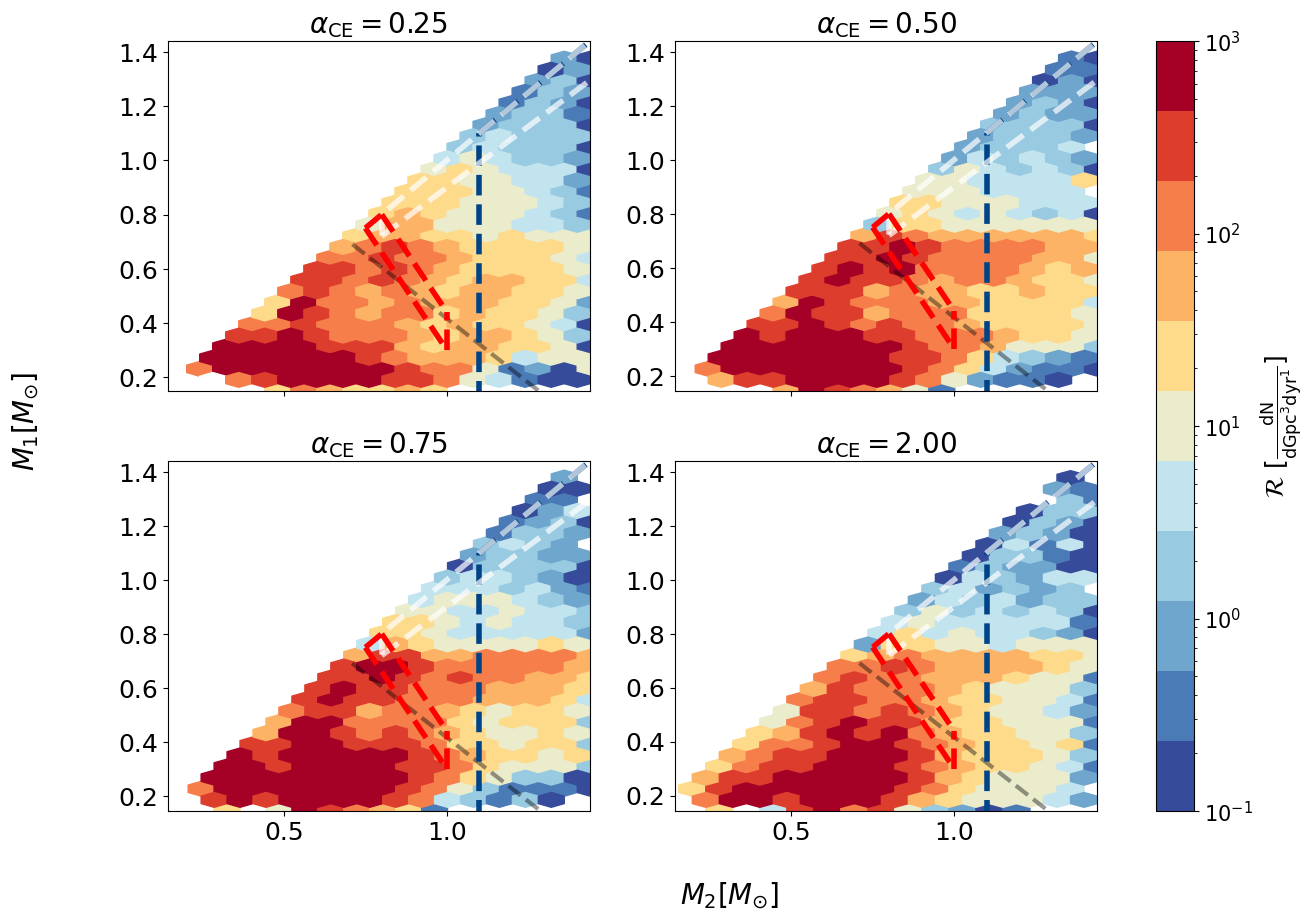

In [31]:

fig, ax = plt.subplots(
    2, 2,
    sharex=True,
    figsize=(15, 10))

cset_c = tc.medium_contrast

vmin = 10**-1
vmax = 10**3

hb_025 = ax[0,0].hexbin(masses_025[2],masses_025[3],C=local_rates_025[1], gridsize=(15,15), reduce_C_function = np.sum, 
                    cmap="tol.sunset_discrete",norm='log',vmin=vmin,vmax=vmax) # C is how much each point is weighted

hb_05 = ax[0,1].hexbin(masses_05[2],masses_05[3],C=local_rates_05[1], gridsize=(15,15), reduce_C_function = np.sum, 
                    cmap="tol.sunset_discrete",norm='log',vmin=vmin,vmax=vmax) # C is how much each point is weighted

hb_075 = ax[1,0].hexbin(masses_075[2],masses_075[3],C=local_rates_075[1], gridsize=(15,15), reduce_C_function = np.sum, 
                    cmap="tol.sunset_discrete",norm='log',vmin=vmin,vmax=vmax) # C is how much each point is weighted

hb_2= ax[1,1].hexbin(masses_2[2],masses_2[3],C=local_rates_2[1], gridsize=(15,15), reduce_C_function = np.sum, 
                    cmap="tol.sunset_discrete",norm='log',vmin=vmin,vmax=vmax) # C is how much each point is weighted


cb_2 = fig.colorbar(hb_2, ax=ax)
cb_2.set_label(label=r"$\mathcal{R}$ [$\frac{\mathrm{dN}}{\mathrm{dGpc^{3}dyr^{1}}}$]", fontsize = 18)
cb_2.ax.tick_params(labelsize=15)


max_mass_lim = 1.44

linecolors = 'white'
linewidths = 4
# # chandrasekar mass line
ax[0,0].plot((1.44,0.7),(0,0.7),color='black', lw=3, ls='--', alpha = 0.4)
# ax[0,0].annotate(r"$\rm{M}_{\rm{TOT}}>1.4\rm{M}_{\odot}$", xy=(0.75, 0.64), xytext=(0.45, 0.45), fontsize=11, color='black', arrowprops=dict(alpha=0.7,arrowstyle='->'))

# # violent merger - unequal
ax[0,0].vlines(x=[1.1], ymin=0, ymax=1.1, colors=cset_c.dark_blue, ls='--', lw=linewidths) # vertical line
ax[0,0].plot([1.1,max_mass_lim],[1.1,max_mass_lim],color=cset_c.dark_blue,lw=linewidths, ls='--') # horizontal line
# ax[0,0].annotate(r"Violent Merger - Unequal", xy=(1.25, 1), xytext=(0.65, 1.3), fontsize=11, color=cset_c.dark_blue, arrowprops=dict(color=cset_c.dark_blue,alpha=0.7,arrowstyle='->'))

# # violent merger - equal
ax[0,0].plot([0.75,max_mass_lim],[0.75,max_mass_lim],color=linecolors,ls='--', lw=linewidths, alpha=0.7) # top boundary
ax[0,0].plot([0.8,max_mass_lim],[0.72,max_mass_lim*0.9],color=linecolors,ls='--', lw=linewidths, alpha=0.7) # bottom boundary
ax[0,0].plot([0.8,0.8],[0.8,0.72],color=linecolors,ls='--', lw=linewidths, alpha=0.7) # side boundary
# ax[0,0].annotate(r"Violent Merger - Equal", xy=(0.95, 0.9), xytext=(0.5, 1.1), fontsize=11, color='black', arrowprops=dict(color='black',alpha=0.7,arrowstyle='->'))

# Shen HVS SNe Ia
ax[0,0].plot([0.8,1],[0.8,0.44],color='red',ls='--', lw=4) # overlapping boundary
ax[0,0].plot([0.75,1.0],[0.75,0.3],'red', ls='--', lw=4) # bottom boundary
ax[0,0].plot([1.0,1.0],[0.3,0.44],'red', ls='--', lw=4) # side boundary
ax[0,0].plot([0.75,0.8],[0.75,0.8],'red',ls='--', lw=4) # top boundary
# ax[0,0].annotate(r"Shen 2025 $\mathrm{D^6}$ HVS", xy=(0.75, 0.77), xytext=(0.4, 0.85), fontsize=11, color='red', arrowprops=dict(color='red', alpha=0.7,arrowstyle='->'))



# # chandrasekar mass line
ax[0,1].plot((1.44,0.7),(0,0.7),color='black', lw=3, ls='--', alpha = 0.4)
# ax[0,1].annotate(r"$\rm{M}_{\rm{TOT}}>1.4\rm{M}_{\odot}$", xy=(0.75, 0.64), xytext=(0.45, 0.45), fontsize=15, color='black', arrowprops=dict(alpha=0.7,arrowstyle='->'))

# # violent merger - unequal
ax[0,1].vlines(x=[1.1], ymin=0, ymax=1.1, colors=cset_c.dark_blue, ls='--', lw=linewidths) # vertical line
ax[0,1].plot([1.1,max_mass_lim],[1.1,max_mass_lim],color=cset_c.dark_blue,lw=linewidths, ls='--') # horizontal line
# ax[0,1].annotate(r"Violent Merger - Unequal", xy=(1.25, 1), xytext=(0.65, 1.3), fontsize=11, color=cset_c.dark_blue, arrowprops=dict(color=cset_c.dark_blue,alpha=0.7,arrowstyle='->'))

# # violent merger - equal
ax[0,1].plot([0.75,max_mass_lim],[0.75,max_mass_lim],color=linecolors,ls='--', lw=linewidths, alpha=0.7) # top boundary
ax[0,1].plot([0.8,max_mass_lim],[0.72,max_mass_lim*0.9],color=linecolors,ls='--', lw=linewidths, alpha=0.7) # bottom boundary
ax[0,1].plot([0.8,0.8],[0.8,0.72],color=linecolors,ls='--', lw=linewidths, alpha=0.7) # side boundary
# ax[0,1].annotate(r"Violent Merger - Equal", xy=(0.95, 0.9), xytext=(0.5, 1.1), fontsize=11, color='black', arrowprops=dict(color='black',alpha=0.7,arrowstyle='->'))

# Shen HVS SNe Ia
ax[0,1].plot([0.8,1],[0.8,0.44],color='red',ls='--', lw=4) # overlapping boundary
ax[0,1].plot([0.75,1.0],[0.75,0.3],'red', ls='--', lw=4) # bottom boundary
ax[0,1].plot([1.0,1.0],[0.3,0.44],'red', ls='--', lw=4) # side boundary
ax[0,1].plot([0.75,0.8],[0.75,0.8],'red',ls='--', lw=4) # top boundary
# ax[0,1].annotate(r"Shen 2025 $\mathrm{D^6}$ HVS", xy=(0.75, 0.77), xytext=(0.4, 0.85), fontsize=11, color='red', arrowprops=dict(color='red', alpha=0.7,arrowstyle='->'))




# # chandrasekar mass line
ax[1,0].plot((1.44,0.7),(0,0.7),color='black', lw=3, ls='--', alpha = 0.4)
# ax[1,0].annotate(r"$\rm{M}_{\rm{TOT}}>1.4\rm{M}_{\odot}$", xy=(0.75, 0.64), xytext=(0.45, 0.45), fontsize=11, color='black', arrowprops=dict(alpha=0.7,arrowstyle='->'))

# # violent merger - unequal
ax[1,0].vlines(x=[1.1], ymin=0, ymax=1.1, colors=cset_c.dark_blue, ls='--', lw=linewidths) # vertical line
ax[1,0].plot([1.1,max_mass_lim],[1.1,max_mass_lim],color=cset_c.dark_blue,lw=linewidths, ls='--') # horizontal line
# ax[1,0].annotate(r"Violent Merger - Unequal", xy=(1.25, 1), xytext=(0.65, 1.3), fontsize=11, color=cset_c.dark_blue, arrowprops=dict(color=cset_c.dark_blue,alpha=0.7,arrowstyle='->'))

# # violent merger - equal
ax[1,0].plot([0.75,max_mass_lim],[0.75,max_mass_lim],color=linecolors,ls='--', lw=linewidths, alpha=0.7) # top boundary
ax[1,0].plot([0.8,max_mass_lim],[0.72,max_mass_lim*0.9],color=linecolors,ls='--', lw=linewidths, alpha=0.7) # bottom boundary
ax[1,0].plot([0.8,0.8],[0.8,0.72],color=linecolors,ls='--', lw=linewidths, alpha=0.7) # side boundary
# ax[1,0].annotate(r"Violent Merger - Equal", xy=(0.95, 0.9), xytext=(0.5, 1.1), fontsize=11, color='black', arrowprops=dict(color='black',alpha=0.7,arrowstyle='->'))

# Shen HVS SNe Ia
ax[1,0].plot([0.8,1],[0.8,0.44],color='red',ls='--', lw=4) # overlapping boundary
ax[1,0].plot([0.75,1.0],[0.75,0.3],'red', ls='--', lw=4) # bottom boundary
ax[1,0].plot([1.0,1.0],[0.3,0.44],'red', ls='--', lw=4) # side boundary
ax[1,0].plot([0.75,0.8],[0.75,0.8],'red',ls='--', lw=4) # top boundary
# ax[1,0].annotate(r"Shen 2025 $\mathrm{D^6}$ HVS", xy=(0.75, 0.77), xytext=(0.4, 0.85), fontsize=11, color='red', arrowprops=dict(color='red', alpha=0.7,arrowstyle='->'))



# # chandrasekar mass line
ax[1,1].plot((1.44,0.7),(0,0.7),color='black', lw=3, ls='--', alpha = 0.4)
# ax[1,1].annotate(r"$\rm{M}_{\rm{TOT}}>1.4\rm{M}_{\odot}$", xy=(0.75, 0.64), xytext=(0.45, 0.45), fontsize=11, color='black', arrowprops=dict(alpha=0.7,arrowstyle='->'))

# # violent merger - unequal
ax[1,1].vlines(x=[1.1], ymin=0, ymax=1.1, colors=cset_c.dark_blue, ls='--', lw=linewidths) # vertical line
ax[1,1].plot([1.1,max_mass_lim],[1.1,max_mass_lim],color=cset_c.dark_blue,lw=linewidths, ls='--') # horizontal line
# ax[1,1].annotate(r"Violent Merger - Unequal", xy=(1.25, 1), xytext=(0.65, 1.3), fontsize=11, color=cset_c.dark_blue, arrowprops=dict(color=cset_c.dark_blue,alpha=0.7,arrowstyle='->'))

# # violent merger - equal
ax[1,1].plot([0.75,max_mass_lim],[0.75,max_mass_lim],color=linecolors,ls='--', lw=linewidths, alpha=0.7) # top boundary
ax[1,1].plot([0.8,max_mass_lim],[0.72,max_mass_lim*0.9],color=linecolors,ls='--', lw=linewidths, alpha=0.7) # bottom boundary
ax[1,1].plot([0.8,0.8],[0.8,0.72],color=linecolors,ls='--', lw=linewidths, alpha=0.7) # side boundary
# ax[1,1].annotate(r"Violent Merger - Equal", xy=(0.95, 0.9), xytext=(0.5, 1.1), fontsize=11, color='black', arrowprops=dict(color='black',alpha=0.7,arrowstyle='->'))

# Shen HVS SNe Ia
ax[1,1].plot([0.8,1],[0.8,0.44],color='red',ls='--', lw=4) # overlapping boundary
ax[1,1].plot([0.75,1.0],[0.75,0.3],'red', ls='--', lw=4) # bottom boundary
ax[1,1].plot([1.0,1.0],[0.3,0.44],'red', ls='--', lw=4) # side boundary
ax[1,1].plot([0.75,0.8],[0.75,0.8],'red',ls='--', lw=4) # top boundary
# ax[1,1].annotate(r"Shen 2025 $\mathrm{D^6}$ HVS", xy=(0.75, 0.77), xytext=(0.4, 0.85), fontsize=11, color='red', arrowprops=dict(color='red', alpha=0.7,arrowstyle='->'))

ax[0,0].set_ylim(min(masses_025[3]),max_mass_lim)
ax[0,0].set_xlim(min(masses_025[3]),max_mass_lim)

ax[0,1].set_ylim(min(masses_05[3]),max_mass_lim)
ax[0,1].set_xlim(min(masses_05[3]),max_mass_lim)

ax[1,0].set_ylim(min(masses_075[3]),max_mass_lim)
ax[1,0].set_xlim(min(masses_075[3]),max_mass_lim)

ax[1,1].set_ylim(min(masses_2[3]),max_mass_lim)
ax[1,1].set_xlim(min(masses_2[3]),max_mass_lim)

ax[0,0].tick_params(axis='both', labelsize=18)
ax[0,1].tick_params(axis='both', labelsize=18)
ax[1,0].tick_params(axis='both', labelsize=18)
ax[1,1].tick_params(axis='both', labelsize=18)

fig.supylabel("$M_{1}$[$M_{\odot}$]",fontsize=20)
fig.supxlabel("$M_{2}$[$M_{\odot}$]",fontsize=20)


# ax.set_title("Fiducial: DWD Mass Distribution", fontsize=15)

ax[0,0].set_title(r"$\alpha_{\mathrm{CE}}=0.25$", fontsize=20)
ax[0,1].set_title(r"$\alpha_{\mathrm{CE}}=0.50$", fontsize=20)
ax[1,0].set_title(r"$\alpha_{\mathrm{CE}}=0.75$", fontsize=20)
ax[1,1].set_title(r"$\alpha_{\mathrm{CE}}=2.00$", fontsize=20)

## save figure:
# plt.savefig("../figures/mass_dist_DWD_variations.png",bbox_inches='tight',pad_inches=0.1)

Text(0.5, 1.0, '$\\alpha_{\\mathrm{CE}}=2.00$')

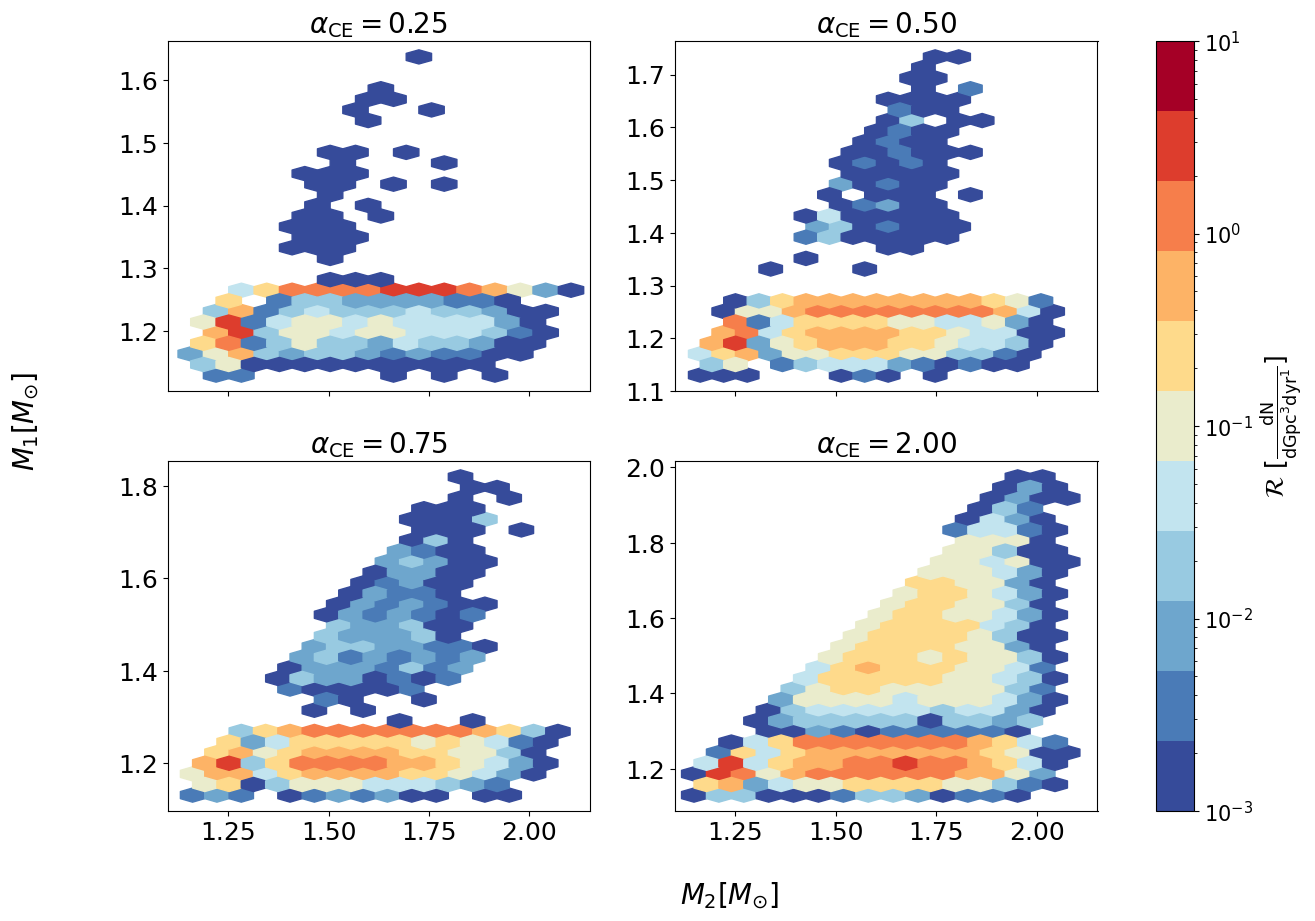

In [39]:

fig, ax = plt.subplots(
    2, 2,
    sharex=True,
    figsize=(15, 10))

cset_c = tc.medium_contrast

vmin = 10**-3
vmax = 10**1

hb_025 = ax[0,0].hexbin(masses_025[0],masses_025[1],C=local_rates_025[0], gridsize=(15,15), reduce_C_function = np.sum, 
                    cmap="tol.sunset_discrete",norm='log',vmin=vmin,vmax=vmax) # C is how much each point is weighted

hb_05 = ax[0,1].hexbin(masses_05[0],masses_05[1],C=local_rates_05[0], gridsize=(15,15), reduce_C_function = np.sum, 
                    cmap="tol.sunset_discrete",norm='log',vmin=vmin,vmax=vmax) # C is how much each point is weighted

hb_075 = ax[1,0].hexbin(masses_075[0],masses_075[1],C=local_rates_075[0], gridsize=(15,15), reduce_C_function = np.sum, 
                    cmap="tol.sunset_discrete",norm='log',vmin=vmin,vmax=vmax) # C is how much each point is weighted

hb_2= ax[1,1].hexbin(masses_2[0],masses_2[1],C=local_rates_2[0], gridsize=(15,15), reduce_C_function = np.sum, 
                    cmap="tol.sunset_discrete",norm='log',vmin=vmin,vmax=vmax) # C is how much each point is weighted


cb_2 = fig.colorbar(hb_2, ax=ax)
cb_2.set_label(label=r"$\mathcal{R}$ [$\frac{\mathrm{dN}}{\mathrm{dGpc^{3}dyr^{1}}}$]", fontsize = 18)
cb_2.ax.tick_params(labelsize=15)


ax[0,0].tick_params(axis='both', labelsize=18)
ax[0,1].tick_params(axis='both', labelsize=18)
ax[1,0].tick_params(axis='both', labelsize=18)
ax[1,1].tick_params(axis='both', labelsize=18)

fig.supylabel("$M_{1}$[$M_{\odot}$]",fontsize=20)
fig.supxlabel("$M_{2}$[$M_{\odot}$]",fontsize=20)


# ax.set_title("Fiducial: DWD Mass Distribution", fontsize=15)

ax[0,0].set_title(r"$\alpha_{\mathrm{CE}}=0.25$", fontsize=20)
ax[0,1].set_title(r"$\alpha_{\mathrm{CE}}=0.50$", fontsize=20)
ax[1,0].set_title(r"$\alpha_{\mathrm{CE}}=0.75$", fontsize=20)
ax[1,1].set_title(r"$\alpha_{\mathrm{CE}}=2.00$", fontsize=20)

## save figure:
# plt.savefig("../figures/mass_dist_NSNS_variations.png",bbox_inches='tight',pad_inches=0.1)